In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import shap
from src.data_prep.pre_process import get_features_df
from src.models.Features_Models_Selection import feature_selection, model_selection
from src.models.models_functions import model
from src.models.Parameters_Tuning.best_param_to_xl import get_best_params_set_xgb, get_best_param_optuna

shap.initjs()

In [8]:
rna_type = 'p'

data = get_features_df(rna_type=rna_type)

RNA_X_train_features = data[f'RNA{rna_type}_X_train']
RNA_y_train = data[f'RNA{rna_type}_y_train']

RNA_X_val_features = data[f'RNA{rna_type}_X_val']
RNA_y_val = data[f'RNA{rna_type}_y_val']

RNA_X_test_features = data[f'RNA{rna_type}_X_test']
RNA_y_test = data[f'RNA{rna_type}_y_test']


In [9]:
param_dict = model_selection(RNA_X_train_features, RNA_X_val_features, RNA_y_train, RNA_y_val, rna_type)
models = ['XGBoost', 'CatBoostRegressor', 'LGBMRegressor', 'RandomForest']

In [5]:
RNAp_selected_features_data = feature_selection(RNAp_X_train_features, RNAp_y_train, rna_type = 'p')
RNAp_selected_features = RNAp_selected_features_data['selected_features']
RNAp_FS_train = RNAp_X_train_features[RNAp_selected_features]
RNAp_FS_val = RNAp_X_val_features[RNAp_selected_features]
RNAp_FS_test = RNAp_X_test_features[RNAp_selected_features]


In [8]:
current_dir = os.getcwd()
excel_file_path = os.path.join(os.path.dirname(os.path.dirname(current_dir)), 'xgb_RNAp_best_params.xlsx')
df = pd.read_excel(excel_file_path)
score = df['scores'].max()
params = df.iloc[df['scores'].idxmax(),:].dropna().drop('scores')
Best_param_xgb = dict(params)
Best_param_xgb['max_depth'] = int(Best_param_xgb['max_depth'])
Best_param_xgb['n_estimators'] = int(Best_param_xgb['n_estimators'])

Running xgboost for pRNA
R^2 value for xgboost: 0.8338739781931607
the mse score for xgboost 3000.30425
spearman correlation value for xgboost: 0.7961523573259801


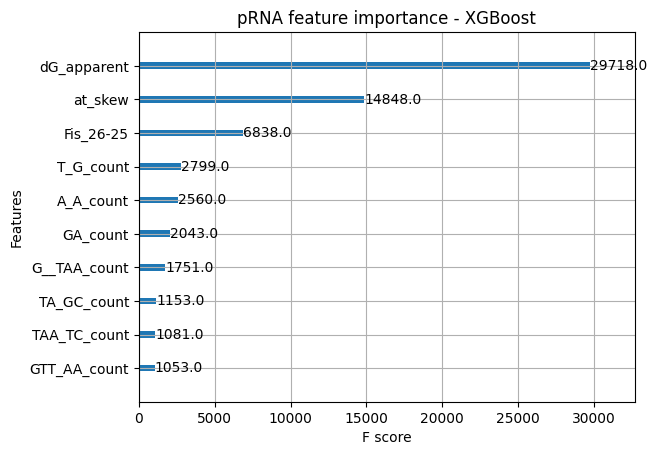

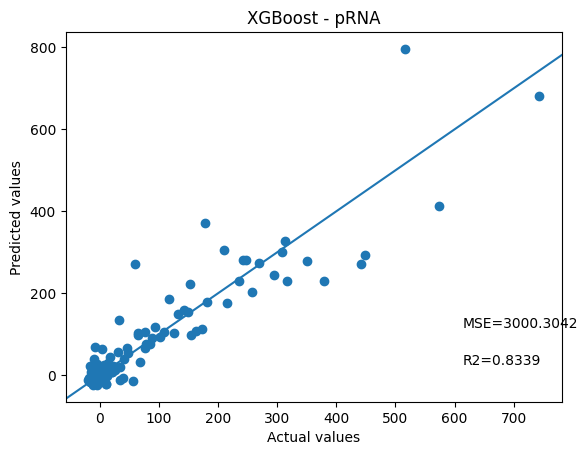

In [10]:
RNAp_FS_train_val_X = pd.concat([RNAp_FS_train, RNAp_FS_val])
RNAp_train_val_y = pd.concat([RNAp_y_train, RNAp_y_val])
trained_model, _, _, _ = model(RNAp_FS_train_val_X, RNAp_FS_test, RNAp_train_val_y, RNAp_y_test,
                                   'xgboost', 'pRNA', Best_param_xgb, save_plots=False)

In [12]:
## IMPORTANT - Before running it you need to either scale the data or remove the scaling from the model (which will show you the non-scaled copy number)
# from src.models.models_functions import scale
# RNAp_FS_train_val_X, RNAp_FS_test = scale(RNAp_FS_train_val_X, RNAp_FS_test)
RNAp_FS_train_val_X = pd.concat([RNAp_FS_train_val_X, RNAp_FS_test])
RNAp_train_val_y = pd.concat([RNAp_train_val_y, RNAp_y_test])

y_pred = trained_model.predict(RNAp_FS_train_val_X)
explainer = shap.Explainer(trained_model)
shap_values = explainer(RNAp_FS_train_val_X)

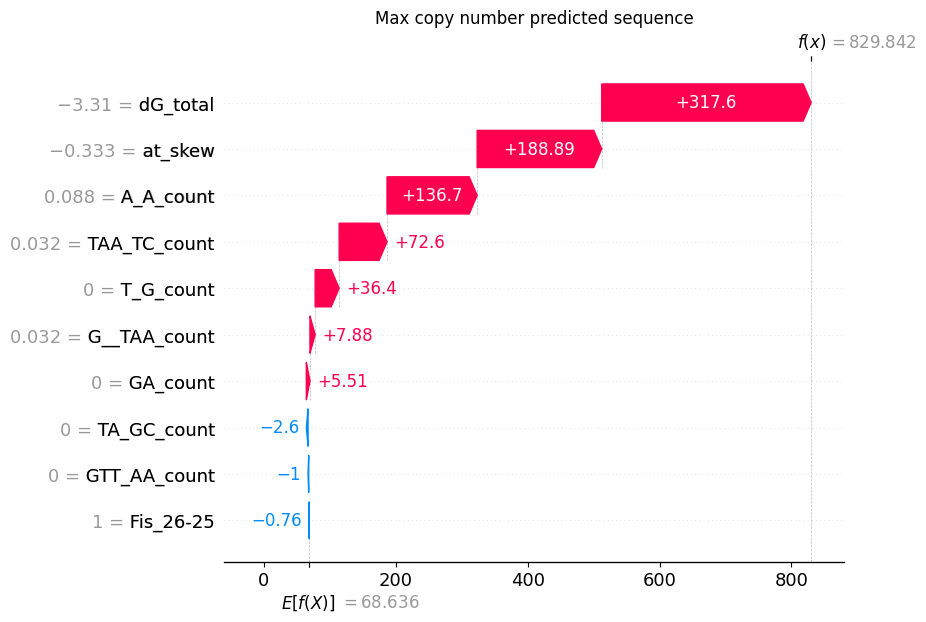

In [7]:
plt.title('Max copy number predicted sequence')
shap.plots.waterfall(shap_values[np.argmax(y_pred)], max_display=10)

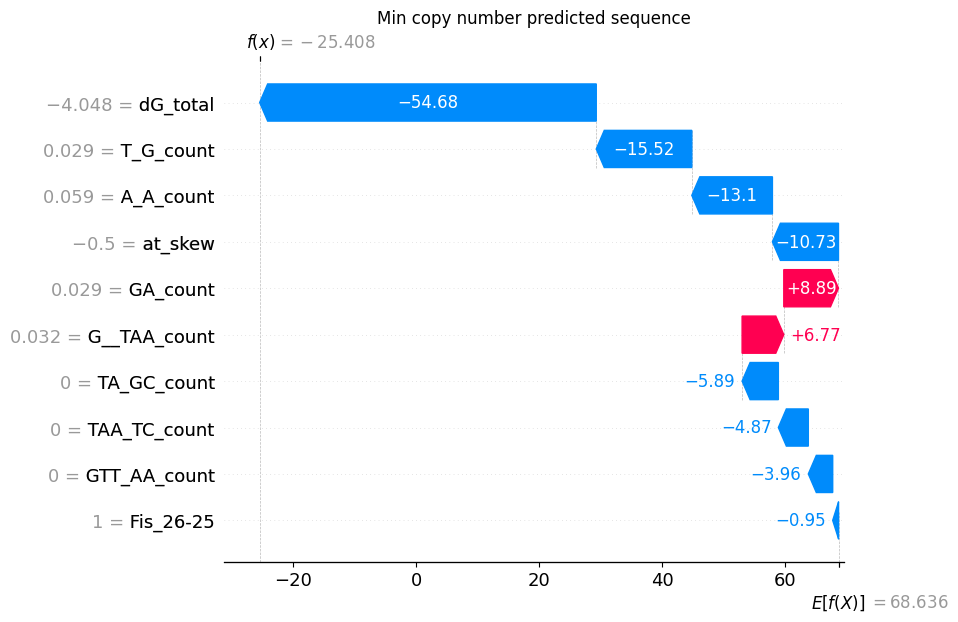

In [8]:
plt.title('Min copy number predicted sequence')
shap.plots.waterfall(shap_values[np.argmin(y_pred)], max_display=10)

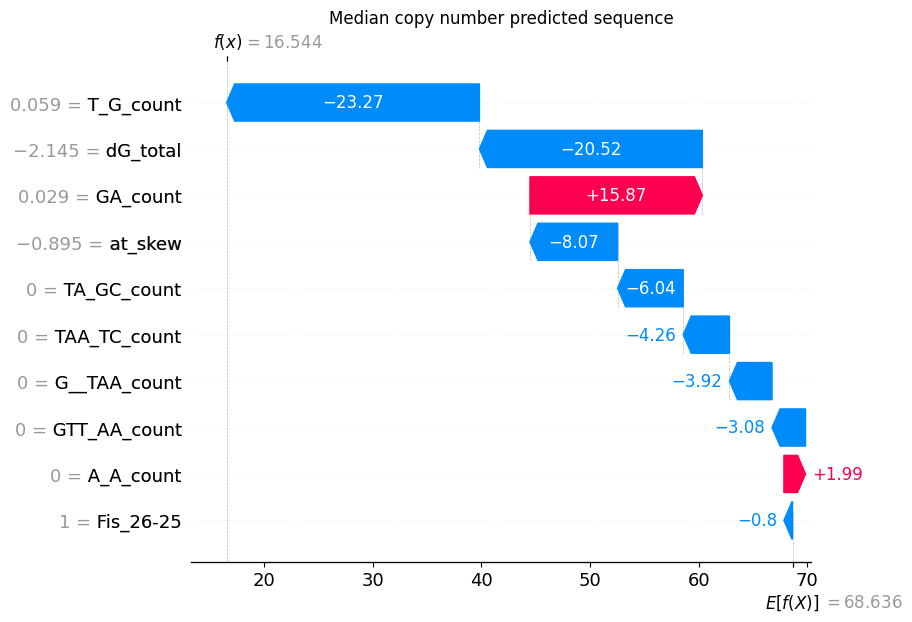

In [9]:
plt.title('Median copy number predicted sequence')
shap.plots.waterfall(shap_values[np.argsort(y_pred)[len(y_pred)//2]],max_display=10)


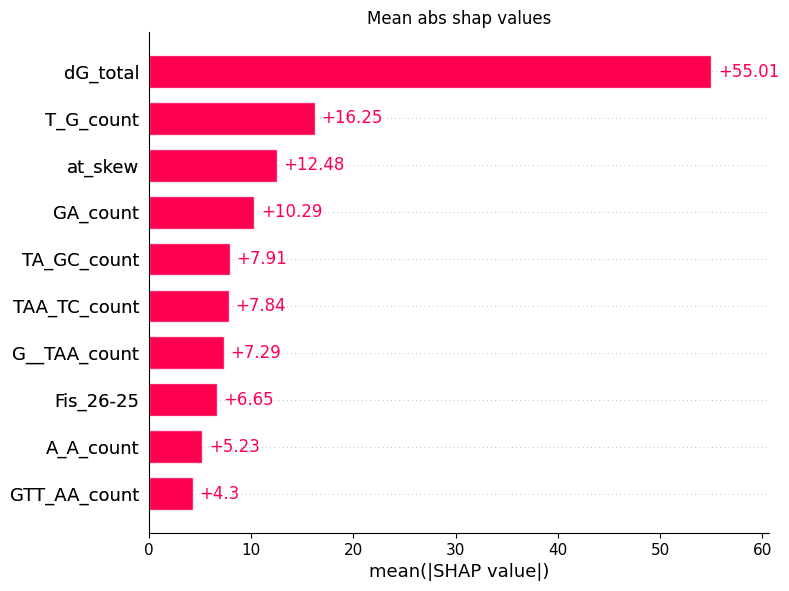

In [10]:
plot = shap.force_plot(explainer.expected_value, shap_values.values, RNAp_FS_train_val_X, show=False)
shap.save_html("shap_force_plot.htm", plot)
plt.title('Mean abs shap values')
shap.plots.bar(shap_values)


Free Energy dG total

In [13]:
RNA_X = pd.concat([RNAp_X_train_features, RNAp_X_val_features, RNAp_X_test_features])
RNA_y = pd.concat([RNAp_y_train, RNAp_y_val, RNAp_y_test])
data = pd.concat([RNA_X['dG_total'], RNA_y],axis=1)
copy_number_mean = data['Copy Number'].mean()


Text(0, 0.5, 'Copy number')

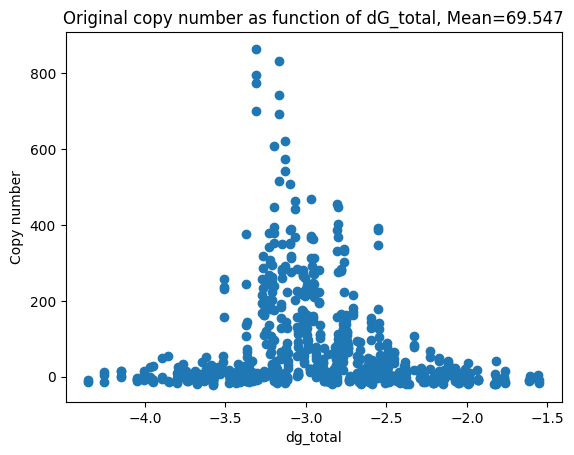

In [14]:
plt.scatter(data['dG_total'], data['Copy Number'])
plt.title(f'Original copy number as function of dG_total, Mean={copy_number_mean:.3f}')
plt.xlabel('dg_total')
plt.ylabel('Copy number')

In [16]:
## Empirical PV

PCN_TH = 150

above_TH = data.loc[data['Copy Number']>PCN_TH]
dG_in_range_above_TH = above_TH[above_TH['dG_total'].between(-3.4, -2.7)]

n_above_TH = above_TH.shape[0]
n_in_range_above_TH = dG_in_range_above_TH.shape[0]
print(f'There are {n_above_TH} sequences above the PCN threshold: {PCN_TH}.')
print(f'There are {n_in_range_above_TH} sequences above the PCN threshold, that are in the dG range of [-3.4,-2.7].')

There are 145 sequences above the PCN threshold: 150.
There are 136 sequences above the PCN threshold, that are in the dG range of [-3.4,-2.7].


In [19]:
num_of_randomizations = 100000
null_counter = 0
for i in range(num_of_randomizations):
    random_sample = data.sample(n_above_TH)
    random_above_TH = random_sample.loc[random_sample['Copy Number']>PCN_TH]
    random_dg_in_range_above_TH = random_above_TH[random_above_TH['dG_total'].between(-3.4, -2.7)]
    random_n_in_range_above_TH = random_dg_in_range_above_TH.shape[0]
    if random_n_in_range_above_TH >= n_in_range_above_TH:
        null_counter +=1
enrichment_pv = null_counter/num_of_randomizations
print(f'Empirical Enrichment pv = {enrichment_pv}')

Empirical Enrichment pv = 0.0


Text(-3.1, 800, '33.0% above TH')

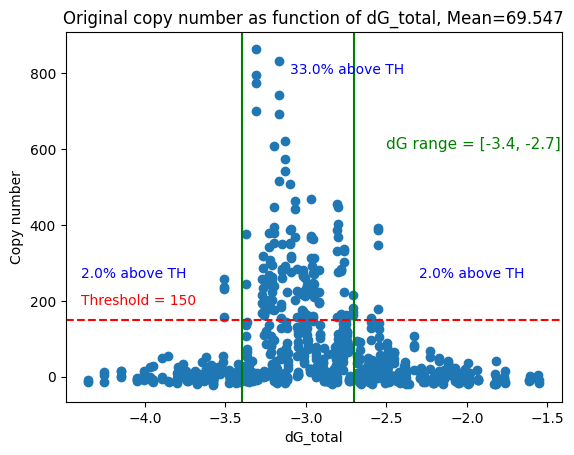

In [83]:
plt.scatter(data['dG_total'], data['Copy Number'])
plt.title(f'Original copy number as function of dG_total, Mean={copy_number_mean:.3f}')
plt.xlabel('dG_total')
plt.ylabel('Copy number')
plt.axhline(PCN_TH, c='r', linestyle='--')
plt.axvline(-3.4, c='g')
plt.axvline(-2.7, c='g')
plt.text(-4.4, 190, f'Threshold = {PCN_TH}', c='r')
plt.text(-2.5, 600, 'dG range = [-3.4, -2.7]', c='g', fontsize=11)

n_left = data.loc[data['dG_total'] <= -3.4].shape[0]
n_right = data.loc[data['dG_total'] >= -2.7].shape[0]
n_mid = data.shape[0] - n_left - n_right

n_left_above = above_TH.loc[above_TH['dG_total'] <= -3.4].shape[0]
n_right_above = above_TH.loc[above_TH['dG_total'] >= -2.7].shape[0]
n_mid_above = above_TH[above_TH['dG_total'].between(-3.4, -2.7)].shape[0]

plt.text(-4.4, 260, f'{np.round(100*(n_left_above/n_left))}% above TH', c='b')
plt.text(-2.3, 260, f'{np.round(100*(n_right_above/n_right))}% above TH', c='b')
plt.text(-3.1, 800, f'{np.round(100*(n_mid_above/n_mid))}% above TH', c='b')


0.004801920768307323

Text(0, 0.5, 'Copy Number')

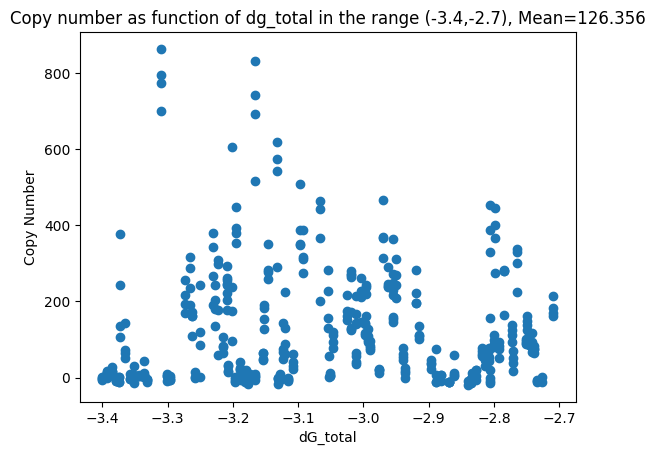

In [16]:
data_dg = data[data['dG_total'].between(-3.4, -2.7)]
plt.scatter(data_dg['dG_total'],data_dg['Copy Number'])
mean_copy_dg = data_dg['Copy Number'].mean()
plt.title(f'Copy number as function of dg_total in the range (-3.4,-2.7), Mean={mean_copy_dg:.3f}')
plt.xlabel('dG_total')
plt.ylabel('Copy Number')

In [17]:
## Analytical PV
import scipy.stats as stats
#hypergeometric distribution
#M- number of sequences #708
#N- number of sequences in the range (-3.4,-2.7) of dG_total #351
#n- number of sequences with high copy number (above 150) #121
#x- number of sequences with high copy number (above 150) in the range #115
M = data.shape[0]
N = data_dg.shape[0]
data_above_150 = data[data['Copy Number']>150]
n = data_above_150.shape[0]
data_dg_above_150 = data_dg[data_dg['Copy Number']>150]
x = data_dg_above_150.shape[0]

In [18]:
#p-value 0, significant
pv=1-stats.hypergeom.cdf(x-1,M,n,N)
print(f'Analytical enrichment pv = {pv}')

Analytical enrichment pv = 0.0
